In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Using a relative path from your notebook's location to the data file
file_path = "Input_Data/01_cleaned_data/uwb_dataset_02a_normalized_class_data.parquet"

# Load the parquet file into a DataFrame
df = pd.read_parquet(file_path)

# Step 2: Separate Targets (Y) from Features (X)
# We do not want to scale the 'NLOS' label or the 'RANGE' target
target_columns = ['NLOS', 'RANGE']

# Get all other columns to act as our features (FP metrics, Noise, RXPACC, and CIRs)
feature_columns = [col for col in df.columns if col not in target_columns]

X = df[feature_columns]
Y = df[target_columns]

# Step 3: Initialize the Scaler
# StandardScaler transforms data to have a mean of 0 and a standard deviation of 1.
# This is generally the best choice for PCA, SVMs, and Neural Networks.
scaler = StandardScaler()

# Step 4: Fit and Transform the features
# The scaler learns the min/max/mean of the data (fit) and applies the math (transform)
X_scaled_array = scaler.fit_transform(X)

# Step 5: Convert the scaled array back into a pandas DataFrame
# fit_transform outputs a raw numpy array, so we put the column names back on
X_scaled = pd.DataFrame(X_scaled_array, columns=feature_columns)

# Step 6: (Optional) Recombine the unscaled targets with the scaled features
# This gives you a clean, fully prepared dataset for the next steps
df_prepared = pd.concat([Y, X_scaled], axis=1)

# Display the first few rows to verify
print("Original FP_AMP1 values:", X['FP_AMP1'].head(3).values)
print("Scaled FP_AMP1 values:  ", X_scaled['FP_AMP1'].head(3).values)
print("\nPrepared Dataset Shape:", df_prepared.shape)

Original FP_AMP1 values: [18712. 11239.  4355.]
Scaled FP_AMP1 values:   [ 1.96253571  0.57691903 -0.69948739]

Prepared Dataset Shape: (42000, 1028)


In [4]:
import pandas as pd
import numpy as np

# Make a copy of the original dataframe to keep it safe
df_clean = df.copy()
print(f"Original Dataset Shape: {df_clean.shape}\n")

# ==========================================
# 1. OUTLIER REMOVAL (Using IQR Method)
# ==========================================
print("--- 1. Outlier Removal ---")
# We will check the hardware noise columns. You can add 'CIR_PWR' or 'RXPACC' to this list if needed.
columns_to_check = ['STDEV_NOISE', 'MAX_NOISE'] 

for col in columns_to_check:
    if col in df_clean.columns:
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        
        # Calculate Interquartile Range (IQR)
        IQR = Q3 - Q1

        # Define bounds for what is considered an "outlier" (1.5x IQR is the statistical standard)
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count how many outliers exist before removing them
        outliers_count = len(df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)])
        print(f"Found {outliers_count} extreme outliers in '{col}'.")

        # Filter the dataframe to KEEP only rows within the normal bounds
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f"Dataset Shape after Outlier Removal: {df_clean.shape}\n")


# ==========================================
# 2. DATA LEAKAGE CHECK (Using Correlation)
# ==========================================
print("--- 2. Data Leakage Check ---")
# Data leakage usually happens if a feature is basically a direct mathematical proxy for your target.
# We test this by checking the Pearson Correlation.

# To keep the calculation fast and readable, we will exclude the 1000+ raw CIR columns for this check
non_cir_cols = [c for c in df_clean.columns if not c.startswith('CIR') or c == 'CIR_PWR']

# Calculate correlation matrix for the non-CIR columns
correlation_matrix = df_clean[non_cir_cols].corr()

# Check correlations against the regression target: RANGE
if 'RANGE' in correlation_matrix.columns:
    # Get the absolute correlation values, sort them highest to lowest
    range_corr = correlation_matrix['RANGE'].abs().sort_values(ascending=False)
    
    print("Top features most correlated with the target 'RANGE':")
    # We skip the 1st one (.head(6)[1:]) because RANGE always has a 1.0 correlation with itself
    print(range_corr.head(6)[1:]) 
    
    # Check for dangerously high correlations (Greater than 95%)
    potential_leaks = range_corr[(range_corr > 0.95) & (range_corr < 1.0)]
    
    if not potential_leaks.empty:
        print("\n⚠️ WARNING: Potential Data Leakage Detected!")
        print("These features have > 0.95 correlation with RANGE. If they are distance estimates rather than raw hardware metrics, you must drop them before training:")
        print(potential_leaks)
    else:
        print("\n✅ Good news: No obvious data leakage detected (No features correlate > 0.95 with RANGE).")

Original Dataset Shape: (42000, 1028)

--- 1. Outlier Removal ---
Found 1915 extreme outliers in 'STDEV_NOISE'.
Found 2717 extreme outliers in 'MAX_NOISE'.
Dataset Shape after Outlier Removal: (37368, 1028)

--- 2. Data Leakage Check ---
Top features most correlated with the target 'RANGE':
RXPACC     0.590807
FP_AMP2    0.452336
FP_AMP3    0.434595
FP_AMP1    0.428159
NLOS       0.417500
Name: RANGE, dtype: float64

✅ Good news: No obvious data leakage detected (No features correlate > 0.95 with RANGE).


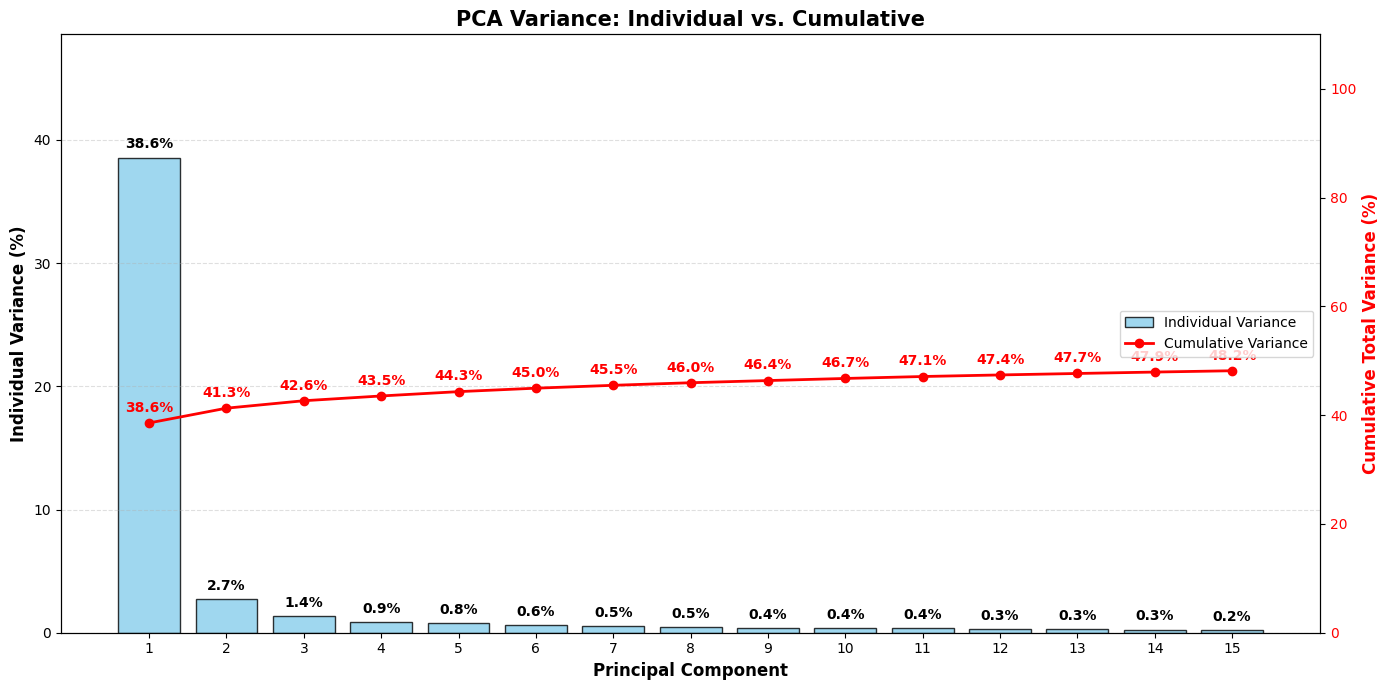

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Assuming pca is already fitted from your previous step:
# pca = PCA(n_components=15)
# pca.fit(X_cir_scaled)

explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100

# Create the main figure and the first axis (for the bars)
fig, ax1 = plt.subplots(figsize=(14, 7))

# 1. Bar Chart for Individual Variance (Left Y-Axis)
bars = ax1.bar(range(1, len(explained_variance) + 1), explained_variance, 
               color='skyblue', edgecolor='black', alpha=0.8, label='Individual Variance')

# Add the exact percentages on top of each bar
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='black')

ax1.set_xlabel('Principal Component', fontsize=12, fontweight='bold')
ax1.set_ylabel('Individual Variance (%)', fontsize=12, color='black', fontweight='bold')
ax1.set_xticks(range(1, len(explained_variance) + 1))
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, max(explained_variance) + 10) # Add some headroom for the text

# 2. Line Chart for Cumulative Variance (Right Y-Axis)
ax2 = ax1.twinx()
line = ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
                color='red', marker='o', linestyle='-', linewidth=2, label='Cumulative Variance')

# Add the exact percentages above the cumulative line points
for i, cum_var in enumerate(cumulative_variance):
    ax2.text(i + 1, cum_var + 1.5, f"{cum_var:.1f}%", 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')

ax2.set_ylabel('Cumulative Total Variance (%)', fontsize=12, color='red', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110) # 100% max, plus some headroom

# Add Title and grid
plt.title('PCA Variance: Individual vs. Cumulative', fontsize=15, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='center right')

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

# 1. Define our columns (Assuming 'df_clean' is your dataset without outliers)
targets = ['NLOS', 'RANGE']
cir_cols = [c for c in df_clean.columns if c.startswith('CIR') and c != 'CIR_PWR']
standard_cols = [c for c in df_clean.columns if c not in targets and c not in cir_cols]

# 2. Separate Features (X) and Target (y)
X = df_clean[standard_cols + cir_cols]
y = df_clean['NLOS'] # We are classifying NLOS

# Split the data into Training and Testing sets (80% train, 20% test)
# stratify=y ensures we have a balanced number of LOS/NLOS in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 3. BUILD THE PREPROCESSING PIPELINE
# ==========================================

# A. What happens to the CIR columns: Scale them, then apply PCA
cir_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA()) # We leave n_components blank; the Grid Search will fill it in!
])

# B. What happens to standard columns (STDEV_NOISE, FP_AMP1, etc.): Only Scale them
standard_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# C. Combine them using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('cir_processing', cir_transformer, cir_cols),
    ('std_processing', standard_transformer, standard_cols)
])

# ==========================================
# 4. BUILD THE FULL MODEL PIPELINE
# ==========================================
# This connects the preprocessor directly to our proxy classifier
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1))
])

# ==========================================
# 5. RUN THE GRID SEARCH
# ==========================================
# We tell the grid search to test PCA components from 10 to 50
param_grid = {
    'preprocessor__cir_processing__pca__n_components': [10, 15, 20, 25, 30, 35, 40, 50]
}

print("Starting Grid Search to find optimal PCA components. This may take a minute...")

# cv=5 means it will 5-fold cross-validate every single PCA number to ensure it's not a fluke
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

# ==========================================
# 6. THE RESULTS
# ==========================================
print("\n" + "="*40)
print(f"✅ BEST PCA COMPONENTS: {grid_search.best_params_['preprocessor__cir_processing__pca__n_components']}")
print(f"✅ BEST CROSS-VAL ACCURACY: {grid_search.best_score_ * 100:.2f}%")
print("="*40 + "\n")

# If you want to see how all the other numbers performed:
results = pd.DataFrame(grid_search.cv_results_)
print("Accuracy for each number of components tested:")
for index, row in results.iterrows():
    comps = row['params']['preprocessor__cir_processing__pca__n_components']
    acc = row['mean_test_score'] * 100
    print(f" - {comps:2d} components: {acc:.2f}% accuracy")

Starting Grid Search to find optimal PCA components. This may take a minute...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ BEST PCA COMPONENTS: 25
✅ BEST CROSS-VAL ACCURACY: 86.86%

Accuracy for each number of components tested:
 - 10 components: 86.64% accuracy
 - 15 components: 86.69% accuracy
 - 20 components: 86.72% accuracy
 - 25 components: 86.86% accuracy
 - 30 components: 86.73% accuracy
 - 35 components: 86.73% accuracy
 - 40 components: 86.30% accuracy
 - 50 components: 86.37% accuracy


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import time

# 1. Lock in our winning number
OPTIMAL_PCA_COMPONENTS = 25

print(f"Building pipelines with {OPTIMAL_PCA_COMPONENTS} CIR PCA components...\n")

# 2. Rebuild the preprocessor with the hard-coded optimal number
cir_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=OPTIMAL_PCA_COMPONENTS)) 
])

standard_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('cir_processing', cir_transformer, cir_cols),
    ('std_processing', standard_transformer, standard_cols)
])

# 3. Define the dictionary of all the models you want to test
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5), # 5 is a standard starting point
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42), # High max_iter to ensure convergence
    "Naive Bayes": GaussianNB(),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=42)
}

# 4. Dictionary to store the results
results = {}

# 5. Loop through each model, train it, and test it
for name, classifier in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    
    # Create the full pipeline for this specific model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    # Train the model on the 80% training data
    pipeline.fit(X_train, y_train)
    
    # Make predictions on the 20% unseen test data
    y_pred = pipeline.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    elapsed_time = time.time() - start_time
    
    results[name] = accuracy
    
    print(f"✅ {name} finished in {elapsed_time:.2f} seconds. Accuracy: {accuracy * 100:.2f}%\n")

# 6. Display the final leaderboard
print("="*40)
print("🏆 FINAL MODEL LEADERBOARD 🏆")
print("="*40)

# Sort the results from highest accuracy to lowest
sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))

for name, acc in sorted_results.items():
    print(f"{name.ljust(20)}: {acc * 100:.2f}%")

print("="*40)

# 7. (Optional) Print a detailed classification report for the winning model
winning_model_name = list(sorted_results.keys())[0]
print(f"\nDetailed Report for the Winner ({winning_model_name}):")

# Re-predict using the winning model to get the full report
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', models[winning_model_name])])
best_pipeline.fit(X_train, y_train)
best_predictions = best_pipeline.predict(X_test)

print(classification_report(y_test, best_predictions))

Building pipelines with 25 CIR PCA components...

Training Random Forest...
✅ Random Forest finished in 2.95 seconds. Accuracy: 87.05%

Training Decision Tree...
✅ Decision Tree finished in 3.22 seconds. Accuracy: 80.69%

Training KNN...
✅ KNN finished in 3.38 seconds. Accuracy: 85.79%

Training Logistic Regression...
✅ Logistic Regression finished in 1.37 seconds. Accuracy: 84.73%

Training Naive Bayes...
✅ Naive Bayes finished in 1.10 seconds. Accuracy: 81.80%

Training SVM (RBF Kernel)...
✅ SVM (RBF Kernel) finished in 106.96 seconds. Accuracy: 87.37%

🏆 FINAL MODEL LEADERBOARD 🏆
SVM (RBF Kernel)    : 87.37%
Random Forest       : 87.05%
KNN                 : 85.79%
Logistic Regression : 84.73%
Naive Bayes         : 81.80%
Decision Tree       : 80.69%

Detailed Report for the Winner (SVM (RBF Kernel)):
